<a href="https://colab.research.google.com/github/preethi-06r/AI-Vital-Sign-Trend-Detection/blob/main/ECG_Signal_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 77.2 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.


In [ ]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
record = wfdb.rdrecord('100', pn_dir='mitdb')

signal = record.p_signal[:, 0]  # first ECG channel
fs = record.fs  # sampling frequency

print("Sampling Frequency:", fs)
print("Signal Length:", len(signal))

Sampling Frequency: 360
Signal Length: 650000


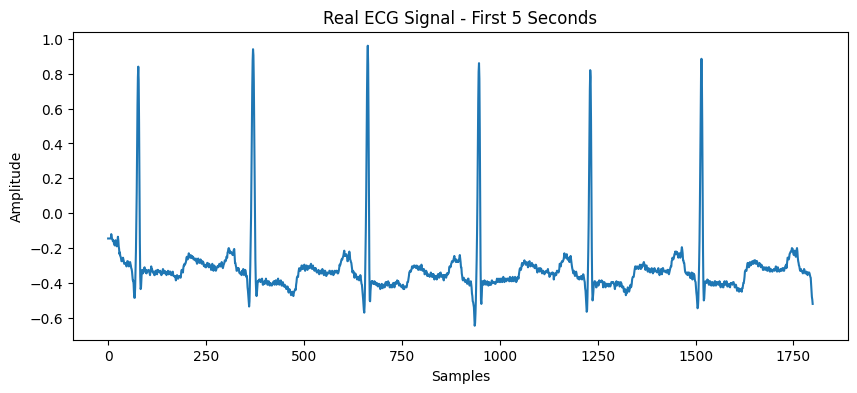

In [ ]:
duration = 5  # seconds
samples = int(fs * duration)

plt.figure(figsize=(10,4))
plt.plot(signal[:samples])
plt.title("Real ECG Signal - First 5 Seconds")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

In [ ]:
from scipy.signal import butter, filtfilt

def lowpass_filter(signal, cutoff=20, fs=360, order=3):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low')
    filtered = filtfilt(b, a, signal)
    return filtered

In [ ]:
filtered_signal = lowpass_filter(signal, fs=fs)

NameError: name 'signal' is not defined

In [ ]:
!pip install wfdb

import wfdb
import numpy as np
import matplotlib.pyplot as plt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 78.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.


In [ ]:
wfdb.dl_database('mitdb', dl_dir='mitdb')

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [ ]:
record = wfdb.rdrecord('mitdb/100')
signal = record.p_signal[:,0]
fs = record.fs

print("Sampling Frequency:", fs)
print("Total Samples:", len(signal))

Sampling Frequency: 360
Total Samples: 650000


In [ ]:
from scipy.signal import butter, filtfilt

def lowpass_filter(signal, cutoff=20, fs=360, order=3):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low')
    filtered = filtfilt(b, a, signal)
    return filtered

In [ ]:
filtered_signal = lowpass_filter(signal, fs=fs)

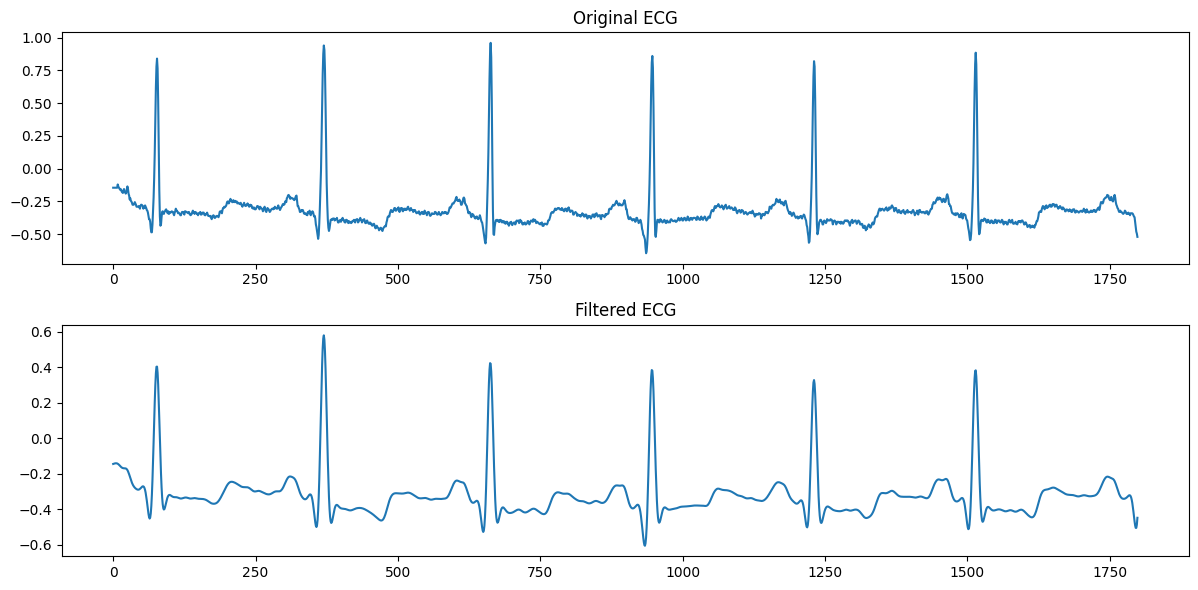

In [ ]:
duration = 5
samples = int(fs * duration)

plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
plt.plot(signal[:samples])
plt.title("Original ECG")

plt.subplot(2,1,2)
plt.plot(filtered_signal[:samples])
plt.title("Filtered ECG")

plt.tight_layout()
plt.show()

In [ ]:
from scipy.signal import find_peaks

# Detect peaks
peaks, _ = find_peaks(filtered_signal, distance=fs*0.6, height=0.5)

print("Number of Peaks Detected:", len(peaks))

Number of Peaks Detected: 1139


In [ ]:
duration_seconds = len(signal) / fs
bpm = (len(peaks) / duration_seconds) * 60

print("Estimated Heart Rate (BPM):", round(bpm,2))

Estimated Heart Rate (BPM): 37.85


In [ ]:
# Calculate RR intervals
rr_intervals = np.diff(peaks)  # difference between consecutive peaks

# Convert to seconds
rr_seconds = rr_intervals / fs

# Calculate average RR interval
mean_rr = np.mean(rr_seconds)

# Heart rate using RR method
bpm_rr = 60 / mean_rr

print("Heart Rate using RR Interval Method:", round(bpm_rr,2))

Heart Rate using RR Interval Method: 37.84


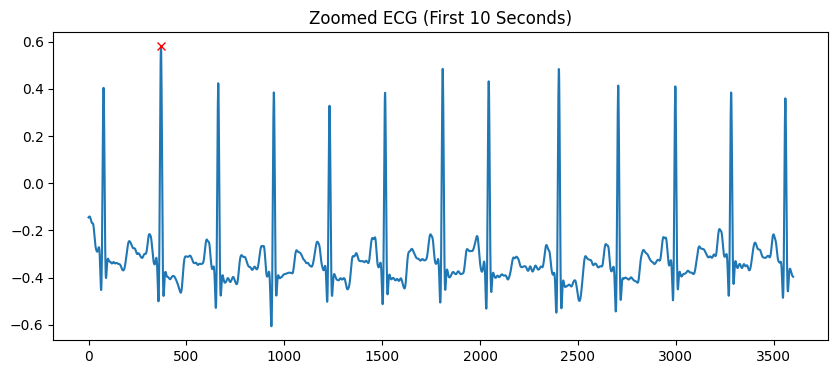

In [ ]:
duration = 10
samples = int(fs * duration)

plt.figure(figsize=(10,4))
plt.plot(filtered_signal[:samples])
plt.plot(peaks[peaks < samples],
         filtered_signal[peaks[peaks < samples]],
         "rx")

plt.title("Zoomed ECG (First 10 Seconds)")
plt.show()

In [ ]:
peaks, _ = find_peaks(filtered_signal,
                      distance=fs*0.4,   # allow closer peaks
                      height=0.3)        # detect smaller peaks

print("New Number of Peaks:", len(peaks))

New Number of Peaks: 2229


In [ ]:
rr_intervals = np.diff(peaks)
rr_seconds = rr_intervals / fs
mean_rr = np.mean(rr_seconds)
bpm_rr = 60 / mean_rr

print("Improved Heart Rate:", round(bpm_rr,2))

Improved Heart Rate: 74.05
